## Linear Regression: Baseline Model

### Exploratory Data Analysis

In [1]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns

from sklearn import metrics
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder

In [2]:
# Load data in dataframe
train_student_data = pd.read_csv("../data/train.csv")
test_student_data = pd.read_csv("../data/test.csv")

train_student_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [3]:
train_student_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  str    
 3   course            630000 non-null  str    
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  str    
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  str    
 9   study_method      630000 non-null  str    
 10  facility_rating   630000 non-null  str    
 11  exam_difficulty   630000 non-null  str    
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), str(7)
memory usage: 62.5 MB


In [4]:
# Drop ID column (redundant)
id_data = test_student_data["id"] # Save ID for submission
train_student_data = train_student_data.drop(columns=["id"])
test_student_data = test_student_data.drop(columns=["id"])

# Explore all unique values for categorical features

print("Unique Gender:", train_student_data["gender"].unique())
print("Unique Course:", train_student_data["course"].unique())
print("Unique Internet Access:", train_student_data["internet_access"].unique())
print("Sleep Quality:", train_student_data["sleep_quality"].unique())
print("Study Method:", train_student_data["study_method"].unique())
print("Facility Rating:", train_student_data["facility_rating"].unique())
print("Exam Difficulty:", train_student_data["exam_difficulty"].unique())

Unique Gender: <StringArray>
['female', 'other', 'male']
Length: 3, dtype: str
Unique Course: <StringArray>
['b.sc', 'diploma', 'bca', 'b.com', 'ba', 'bba', 'b.tech']
Length: 7, dtype: str
Unique Internet Access: <StringArray>
['no', 'yes']
Length: 2, dtype: str
Sleep Quality: <StringArray>
['average', 'poor', 'good']
Length: 3, dtype: str
Study Method: <StringArray>
['online videos', 'self-study', 'coaching', 'group study', 'mixed']
Length: 5, dtype: str
Facility Rating: <StringArray>
['low', 'medium', 'high']
Length: 3, dtype: str
Exam Difficulty: <StringArray>
['easy', 'moderate', 'hard']
Length: 3, dtype: str


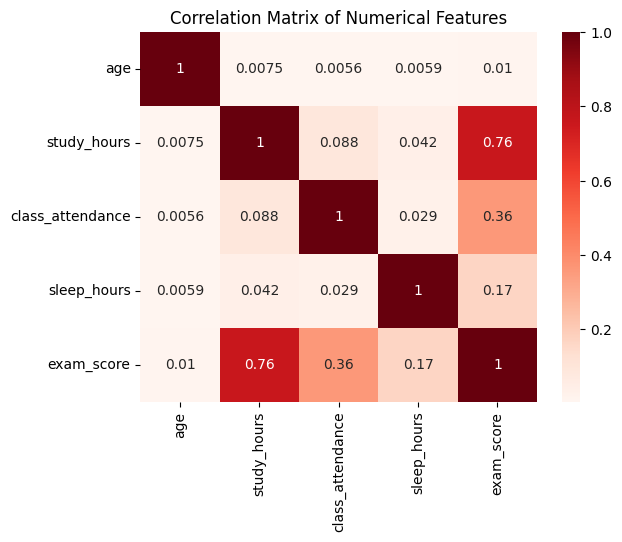

In [5]:
# Analyze correlation between numerical features
numerical_features = ["age", "study_hours", "class_attendance", "sleep_hours", "exam_score"]
corr_matrix = train_student_data[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap="Reds")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [6]:
# Make Internet Access Binary (Yes = 1, No =0)
train_student_data["internet_access"] = train_student_data["internet_access"].map({"yes": 1, "no": 0})
test_student_data["internet_access"] = test_student_data["internet_access"].map({"yes": 1, "no": 0})    

# One Hot Encode remaining categorical features

categorical_features = ["gender","course","sleep_quality","study_method","facility_rating","exam_difficulty"]
one_hot_data = train_student_data[categorical_features]

encoder = OneHotEncoder(drop="first", sparse_output=False) # Avoid multicollinearity

one_hot_encoded = encoder.fit_transform(one_hot_data)
one_hot_names = encoder.get_feature_names_out(categorical_features)

# Replace existing categorical rows
train_student_data = pd.concat(
    [train_student_data.drop(columns=categorical_features), pd.DataFrame(one_hot_encoded, columns=one_hot_names)],
    axis=1
)

test_student_data = pd.concat(
    [test_student_data.drop(columns=categorical_features), pd.DataFrame(encoder.transform(test_student_data[categorical_features]), columns=one_hot_names)],
    axis=1
)

# View all hot encoded categorical features (for viewing)
print(one_hot_names)

['gender_male' 'gender_other' 'course_b.sc' 'course_b.tech' 'course_ba'
 'course_bba' 'course_bca' 'course_diploma' 'sleep_quality_good'
 'sleep_quality_poor' 'study_method_group study' 'study_method_mixed'
 'study_method_online videos' 'study_method_self-study'
 'facility_rating_low' 'facility_rating_medium' 'exam_difficulty_hard'
 'exam_difficulty_moderate']


In [7]:
# Print new dataframe
train_student_data.head()

,age,study_hours,class_attendance,internet_access,sleep_hours,exam_score,gender_male,gender_other,course_b.sc,course_b.tech,...,sleep_quality_good,sleep_quality_poor,study_method_group study,study_method_mixed,study_method_online videos,study_method_self-study,facility_rating_low,facility_rating_medium,exam_difficulty_hard,exam_difficulty_moderate
0,21,7.91,98.8,0,4.9,78.3,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,18,4.95,94.8,1,4.7,46.7,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
2,20,4.68,92.6,1,5.8,99.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,19,2.00,49.5,1,8.3,63.9,1.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,23,7.65,86.9,1,9.6,100.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


### Train Linear Regression

In [8]:
# Remove target feature from feature list
target = "exam_score"

features = list(train_student_data.columns)
features.remove(target)

X_train = train_student_data[features]
y_train = train_student_data[target]

X_test = test_student_data[features]

# Train on linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Print Linear Regression Coefficients
print("Intercept:", lin_reg.intercept_)
pd.DataFrame(lin_reg.coef_, features, columns = ["Coefficient"])

Intercept: 17.72824650268931


,Coefficient
age,-0.013699
study_hours,5.676465
class_attendance,0.312254
internet_access,0.023373
sleep_hours,1.321698
gender_male,-0.105472
gender_other,0.190581
course_b.sc,-0.177876
course_b.tech,0.167018
course_ba,-0.033243


### Evaluate

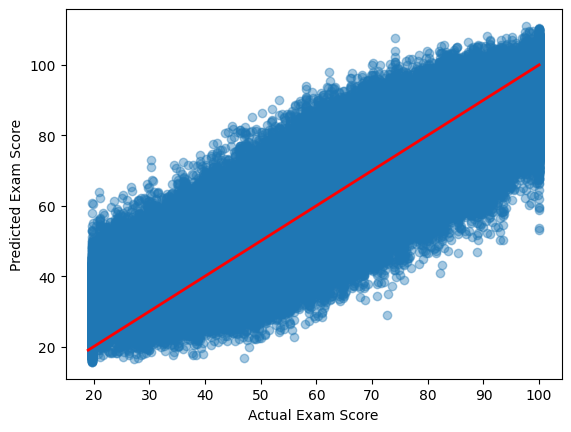

In [9]:
# Evaluate model performance (training data)
y_train_pred = lin_reg.predict(X_train)

# Graph actual vs predicted in scatter plot for training data
plt.scatter(y_train, y_train_pred, alpha=0.4)
plt.plot([19, 100], [19, 100], 'r', lw=2) 

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.show()

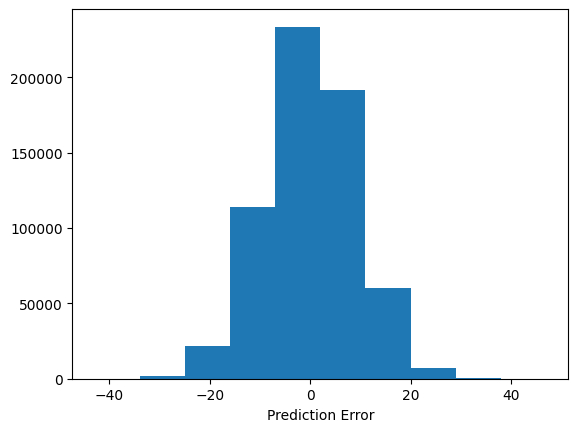

In [10]:
plt.hist(y_train - y_train_pred)
plt.xlabel("Prediction Error")
plt.show()

In [11]:
# Regression Model Evaluation Metrics (training data)

res_metrics = pd.DataFrame({
  "MAE": [metrics.mean_absolute_error(y_train, y_train_pred)],
  "MSE": [metrics.mean_squared_error(y_train, y_train_pred)],
  "RMSE": [np.sqrt(metrics.mean_squared_error(y_train, y_train_pred))],
  "R2": [metrics.r2_score(y_train, y_train_pred)] 
})

pd.set_option("float_format", "{:f}".format)
res_metrics

,MAE,MSE,RMSE,R2
0,7.100962,79.110443,8.894405,0.778927


### Generate Submission

In [12]:
# Generate test predictions
coefficients = np.array(lin_reg.coef_)
exam_score = lin_reg.intercept_ + test_student_data.values.dot(coefficients)

df_lr = pd.DataFrame({
    "id": id_data,
    "exam_score": exam_score
})
df_lr.to_csv("../submission/linear_regression_submission.csv", index=False)
print("Submission saved to ../submission/linear_regression_submission.csv")
df_lr

Submission saved to ../submission/linear_regression_submission.csv


,id,exam_score
0,630000,71.778789
1,630001,69.478481
2,630002,87.434598
3,630003,54.923805
4,630004,47.305416
...,...,...
269995,899995,60.918391
269996,899996,38.932301
269997,899997,89.994391
269998,899998,55.493962
